In [1]:
from transformers import AutoTokenizer, Gemma3ForCausalLM
import torch

m = Gemma3ForCausalLM.from_pretrained("google/gemma-3-4b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=torch.bfloat16, device_map = 'cpu')
tokenizer   = AutoTokenizer.from_pretrained("google/gemma-3-4b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [2]:
from datasets import load_from_disk
ds = load_from_disk("/image-generation/imlloja/filtered-math")
loader = torch.utils.data.DataLoader(ds, batch_size=100, shuffle=False)


Loading dataset from disk:   0%|          | 0/48 [00:00<?, ?it/s]

In [3]:
iterator = enumerate(loader)

In [4]:
i, batch = next(iterator)
lines = batch['text']
batch = tokenizer(lines, max_length=1000, padding=True, truncation=True, return_tensors="pt")
input_ids = batch['input_ids']
attention_mask = batch['attention_mask']

In [5]:
device = 'cuda:1'
m.to(device)
optimizer = torch.optim.AdamW(m.parameters())

In [6]:
input_ids.shape

torch.Size([100, 1000])

In [11]:
cache = {}
def fwd_hook(mod, inp, out):
    cache['X'] = inp[0].detach().clone()
    cache['Y'] = out.detach().clone()

def bwd_hook(mod, grad_inp, grad_out):
    cache['G'] = grad_out[0].detach().clone()



In [12]:
h1 = m.model.layers[-1].mlp.gate_proj.register_forward_hook(fwd_hook)
h2 = m.model.layers[-1].mlp.gate_proj.register_full_backward_hook(bwd_hook)


In [13]:
outputs = m(input_ids=input_ids[:5].to(device), attention_mask=attention_mask[:5].to(device))

In [16]:
m.model.layers[-1].mlp.gate_proj

Linear(in_features=2560, out_features=10240, bias=False)

In [19]:
cache.keys()

dict_keys(['X', 'Y'])

In [20]:
cache['X'].shape, cache['Y'].shape

(torch.Size([5, 1000, 2560]), torch.Size([5, 1000, 10240]))

In [87]:
torch.cuda.empty_cache()
torch.cuda.synchronize()
import gc
gc.collect()

0

In [28]:
tokenizer.decode(input_ids[0])

'<bos>Bayes and his\xa0Theorem\n\nMy earlier post on Bayesian probability seems to have generated quite a lot of readers, so this lunchtime I thought I’d add a little bit of background. The previous discussion started from the result\n\n$P(B|AC) = K^{-1}P(B|C)P(A|BC) = K^{-1} P(AB|C)$\n\nwhere\n\n$K=P(A|C).$\n\nAlthough this is called Bayes’ theorem, the general form of it as stated here was actually first written down, not by Bayes but by Laplace. What Bayes’ did was derive the special case of this formula for “inverting” the binomial distribution. This distribution gives the probability of x successes in n independent “trials” each having the same probability of success, p; each “trial” has only two possible outcomes (“success” or “failure”). Trials like this are usually called Bernoulli trials, after Daniel Bernoulli. If we ask the question “what is the probability of exactly x successes from the possible n?”, the answer is given by the binomial distribution:\n\n$P_n(x|n,p)= C(n,x) 

In [27]:
tokenizer.convert_ids_to_tokens(input_ids[:5, 1])

['Bay', '#', 'T', '#', 'By']

In [24]:
tokenizer.convert_ids_to_tokens([184])

['<h1>']

In [41]:
labels = input_ids[:5].clone()


In [47]:
shifted_logits = outputs.logits[:, :-1].contiguous()
shifted_labels = labels[:, 1:].contiguous()


In [51]:
shifted_logits.view(-1)

tensor([-11.5625,   6.6250,   3.4219,  ...,  -0.0461,  -0.0376,  -0.0535],
       device='cuda:1', dtype=torch.bfloat16, grad_fn=<ViewBackward0>)

In [62]:
losses = torch.nn.functional.cross_entropy(shifted_logits.view(-1, shifted_logits.size(-1)), shifted_labels.view(-1).to(device), reduction='none')

In [63]:
losses

tensor([14.3750,  4.3750,  4.9688,  ...,  4.5312,  1.0156,  0.1201],
       device='cuda:1', dtype=torch.bfloat16, grad_fn=<NllLossBackward0>)

In [65]:
losses.mean().backward()

In [70]:
m.model.layers[-1].mlp.gate_proj.weight.grad.shape

torch.Size([10240, 2560])

In [76]:
cache['X'].shape, cache['Y'].shape, cache['G'].shape, m.model.layers[-1].mlp.gate_proj.weight.grad.shape

(torch.Size([5, 1000, 2560]),
 torch.Size([5, 1000, 10240]),
 torch.Size([5, 1000, 10240]),
 torch.Size([10240, 2560]))

In [94]:
with torch.no_grad():
    print(torch.allclose(cache['X'] @ m.model.layers[-1].mlp.gate_proj.weight.T, cache['Y']))

True


In [78]:
with torch.no_grad():
    print(m.model.layers[-1].mlp.gate_proj.weight.grad - cache['G'].reshape(5000, -1).T @ cache['X'].reshape(5000, -1))

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:1', dtype=torch.bfloat16)


In [125]:
with torch.no_grad():
    outer = torch.zeros_like(m.model.layers[-1].mlp.gate_proj.weight)
    for i in range(5000):
        # outer += cache['G'].reshape(5000, -1)[i].unsqueeze(1) @ cache['X'].reshape(5000, -1)[i].unsqueeze(0)
        outer += G_flat[i].unsqueeze(1) @ X_flat[i].unsqueeze(0)

In [126]:
with torch.no_grad():
    print(outer.shape)
    print( (outer - m.model.layers[-1].mlp.gate_proj.weight.grad).abs().max())

torch.Size([10240, 2560])
tensor(0.0030, device='cuda:1', dtype=torch.bfloat16)


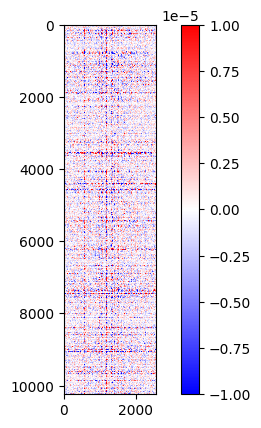

In [84]:
plt.imshow(m.model.layers[-1].mlp.gate_proj.weight.grad.detach().cpu().float().numpy(), cmap='bwr', vmin=-0.00001, vmax=0.00001)
plt.colorbar()

In [66]:
cache.keys()

dict_keys(['X', 'Y', 'G'])

In [97]:
X_flat = cache['X'].reshape(5000, -1)
G_flat = cache['G'].reshape(5000, -1)

In [101]:
print(X_flat.shape,G_flat.shape)

torch.Size([5000, 2560]) torch.Size([5000, 10240])


In [100]:
with torch.no_grad():
    assert(torch.allclose(G_flat.T@X_flat, m.model.layers[-1].mlp.gate_proj.weight.grad))

In [111]:
G_flat.shape, X_flat.shape, V.shape, U.shape, H.shape, S.shape

(torch.Size([5000, 10240]),
 torch.Size([5000, 2560]),
 torch.Size([2560, 2560]),
 torch.Size([10240, 2560]),
 torch.Size([10240, 2560]),
 torch.Size([2560]))

In [161]:
import time
H = m.model.layers[-1].mlp.gate_proj.weight.grad
with torch.no_grad():
    t0 = time.time()
    H = H.float()
    t1 = time.time()
    U, S, Vh = torch.linalg.svd(H.float(), full_matrices=False)
    t2 = time.time()
    V = Vh.mT
    A = G_flat.float() @ U
    B = X_flat.float() @ V

    scores = (A * B) @ S
    t3 = time.time()

In [140]:
running_error = 0
running_abs_error = 0
max_error = float('-inf')
for i in range(5000):
    low_rank_example_update = G_flat[i].unsqueeze(1) @ X_flat[i].unsqueeze(0)
    score_naive = (low_rank_example_update * H).sum()
    running_error += score_naive - scores[i]
    running_abs_error += abs(score_naive - scores[i])
    max_error = max(max_error, abs(score_naive - scores[i]))

In [143]:
max_error, running_error/5000, running_abs_error/5000

(tensor(1.0683e-06, device='cuda:1'),
 tensor(3.9299e-10, device='cuda:1'),
 tensor(1.6575e-08, device='cuda:1'))

In [127]:
low_rank_example_update = G_flat[0].unsqueeze(1) @ X_flat[0].unsqueeze(0)

In [129]:
score_naive = (low_rank_example_update * H).sum()

In [130]:
score_naive

tensor(8.2413e-06, device='cuda:1')

In [135]:
scores[0]

tensor(8.2439e-06, device='cuda:1')

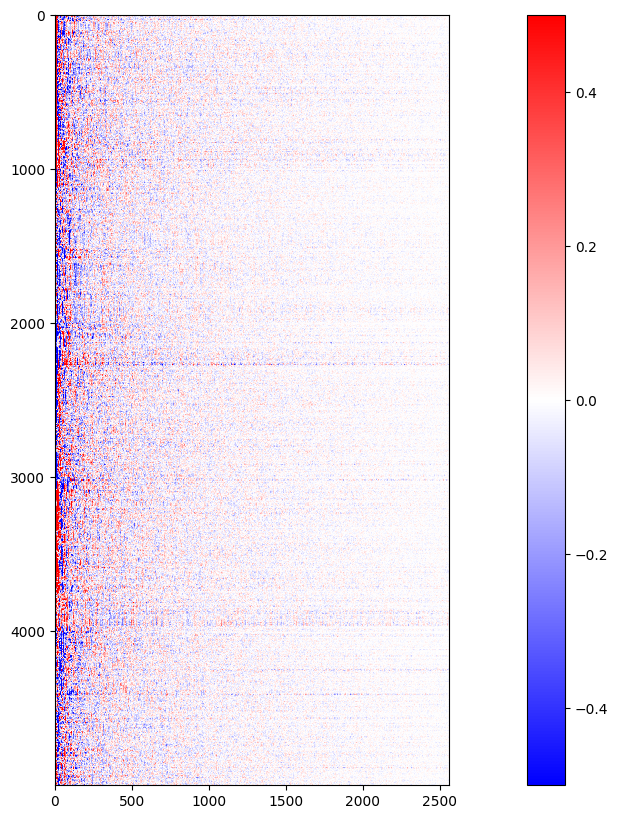

In [180]:
plt.figure(figsize=(20, 10))
plt.imshow(((B) ).detach().float().cpu().numpy(), cmap='bwr', vmin=-5e-1, vmax=5e-1)
plt.colorbar()

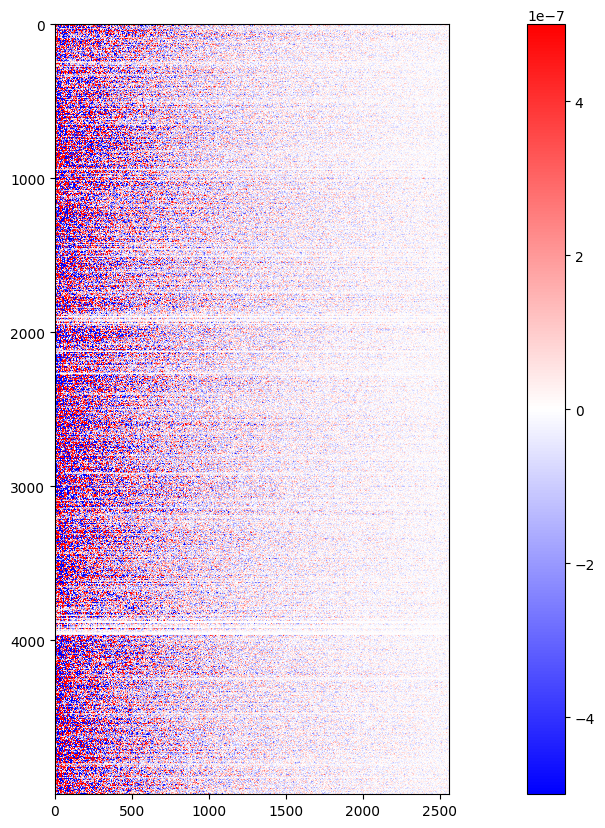

In [177]:
plt.figure(figsize=(20, 10))
plt.imshow(((A) ).detach().float().cpu().numpy(), cmap='bwr', vmin=-5e-7, vmax=5e-7)
plt.colorbar()

In [157]:
(scores > 0).float().mean()

tensor(0.5746, device='cuda:1')

In [147]:
(scores > 0).float().mean()

tensor(0.7230, device='cuda:1')

In [151]:
scores.shape

torch.Size([5000])

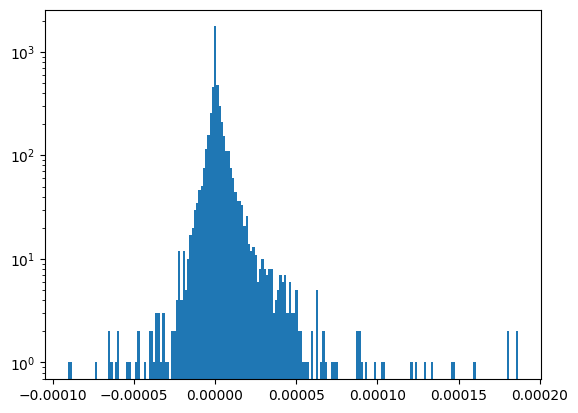

In [158]:
plt.hist(scores.detach().cpu().numpy(), bins=200);
plt.yscale('log')

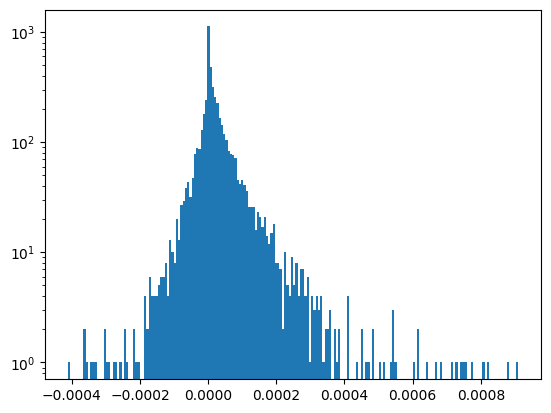

In [139]:
plt.hist(scores.detach().cpu().numpy(), bins=200);
plt.yscale('log')

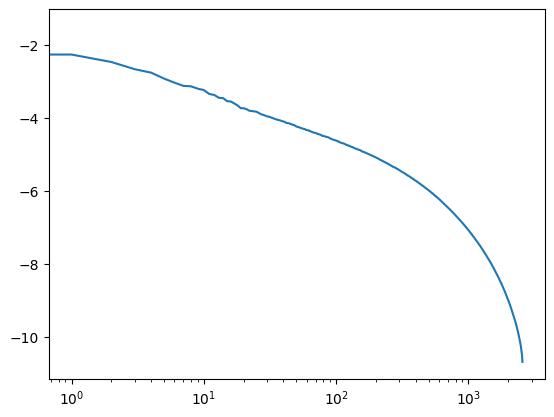

In [185]:
plt.plot(S.log().cpu().detach().float().numpy())
plt.xscale('log')

In [115]:
t3 - t0

0.4770960807800293

In [40]:
import matplotlib.pyplot as plt

torch.exp(torch.log_softmax(outputs.logits[0,0], dim=0)).sum()

tensor(1., device='cuda:1', dtype=torch.bfloat16, grad_fn=<SumBackward0>)